<a href="https://colab.research.google.com/github/Sam50x/5--JS/blob/main/Predict_Customer_Churn_playground_6_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict Customer Churn (Kaggle Playground 6-3)

## Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predict-Customer-Churn--playground-6-3/data/train.csv').set_index('id')
train_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Predict-Customer-Churn--playground-6-3/data/test.csv').set_index('id')
test_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
id,,,,,,,,,,,,,,,,,,,
594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [5]:
df = pd.concat([train_df, test_df])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## EDA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848849 entries, 0 to 848848
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            848849 non-null  object 
 1   SeniorCitizen     848849 non-null  int64  
 2   Partner           848849 non-null  object 
 3   Dependents        848849 non-null  object 
 4   tenure            848849 non-null  int64  
 5   PhoneService      848849 non-null  object 
 6   MultipleLines     848849 non-null  object 
 7   InternetService   848849 non-null  object 
 8   OnlineSecurity    848849 non-null  object 
 9   OnlineBackup      848849 non-null  object 
 10  DeviceProtection  848849 non-null  object 
 11  TechSupport       848849 non-null  object 
 12  StreamingTV       848849 non-null  object 
 13  StreamingMovies   848849 non-null  object 
 14  Contract          848849 non-null  object 
 15  PaperlessBilling  848849 non-null  object 
 16  PaymentMethod     848849 

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,848849.000000,848849.000000,848849.000000,848849.000000
mean,0.113958,36.787995,65.945598,2509.449163
std,0.317760,24.979032,31.078676,2352.291795
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.950000,654.250000
50%,0.000000,35.000000,74.200000,1442.900000
75%,0.000000,62.000000,90.850000,4282.400000
max,1.000000,72.000000,118.750000,8684.800000


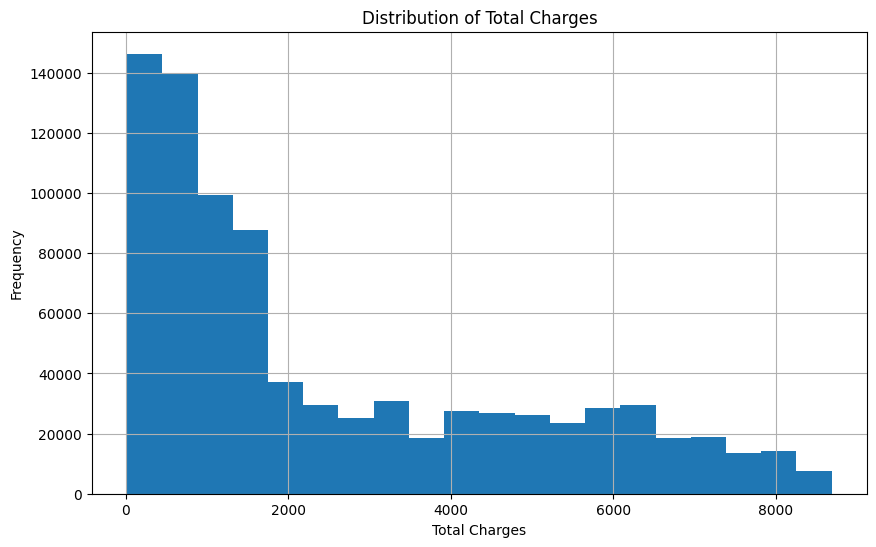

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df['TotalCharges'], bins=20)

plt.xlabel('Total Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Total Charges')

plt.grid()
plt.show()

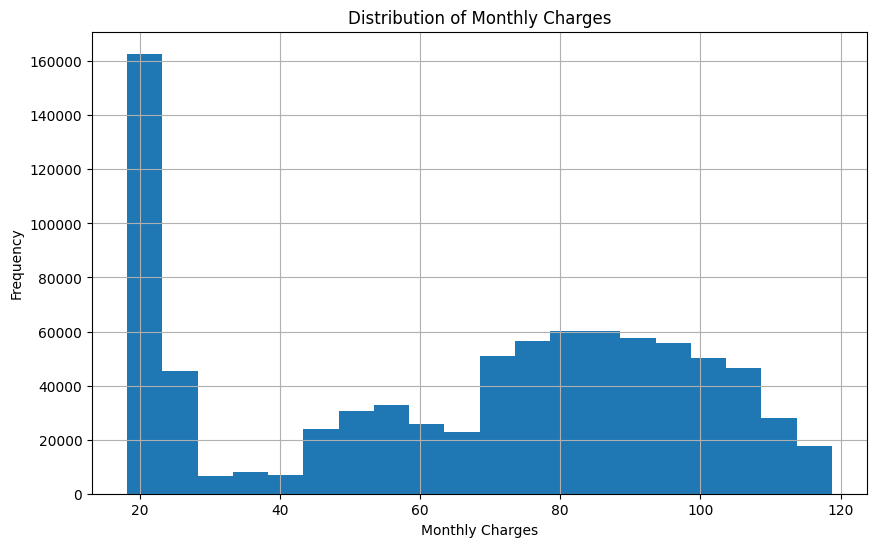

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(df['MonthlyCharges'], bins=20)

plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Monthly Charges')

plt.grid()
plt.show()

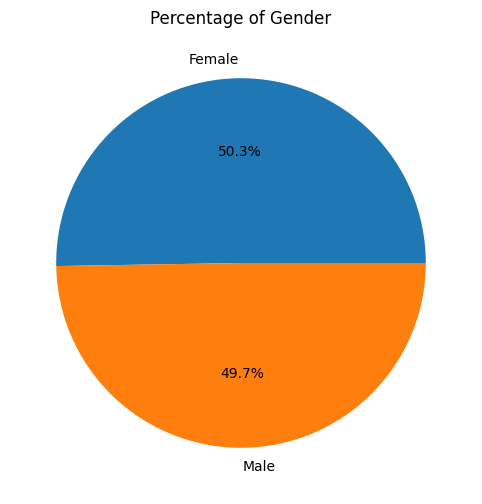

In [10]:
plt.figure(figsize=(10, 6))
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.1f%%')

plt.title('Percentage of Gender')

plt.grid()
plt.show()

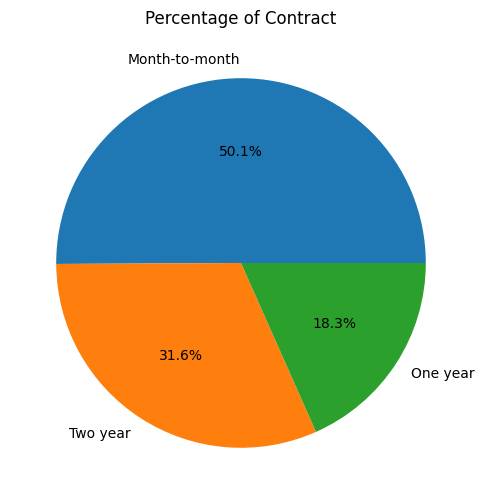

In [11]:
plt.figure(figsize=(10, 6))
plt.pie(df['Contract'].value_counts(), labels=df['Contract'].value_counts().index, autopct='%1.1f%%')

plt.title('Percentage of Contract')

plt.grid()
plt.show()

In [12]:
monthly_charges_per_contract = df.groupby('Contract')['MonthlyCharges'].mean()
monthly_charges_per_contract

,MonthlyCharges
Contract,
Month-to-month,71.458006
One year,63.730759
Two year,58.487789


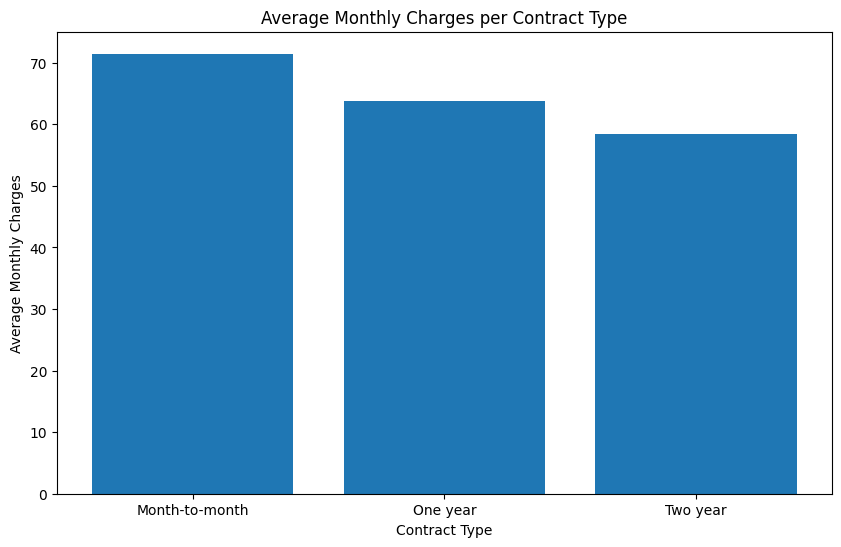

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(monthly_charges_per_contract.index, monthly_charges_per_contract.values)

plt.xlabel('Contract Type')
plt.ylabel('Average Monthly Charges')
plt.title('Average Monthly Charges per Contract Type')

plt.show()

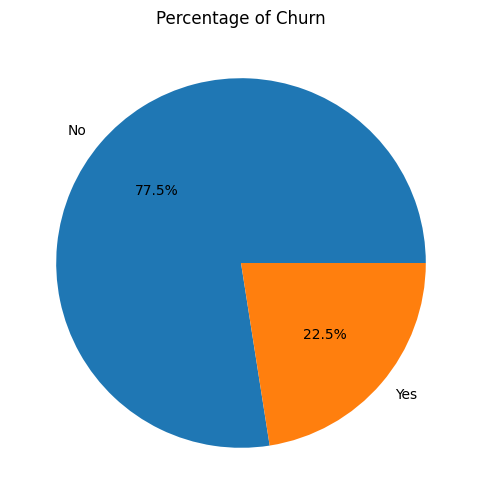

In [14]:
plt.figure(figsize=(10, 6))
plt.pie(df['Churn'].dropna().value_counts(), labels=df['Churn'].dropna().value_counts().index, autopct='%1.1f%%')

plt.title('Percentage of Churn')

plt.show()

I'll need to do some sampling

In [15]:
monthly_charges_per_churn = df.groupby('Churn')['MonthlyCharges'].mean()
monthly_charges_per_churn

,MonthlyCharges
Churn,
No,61.293633
Yes,81.597525


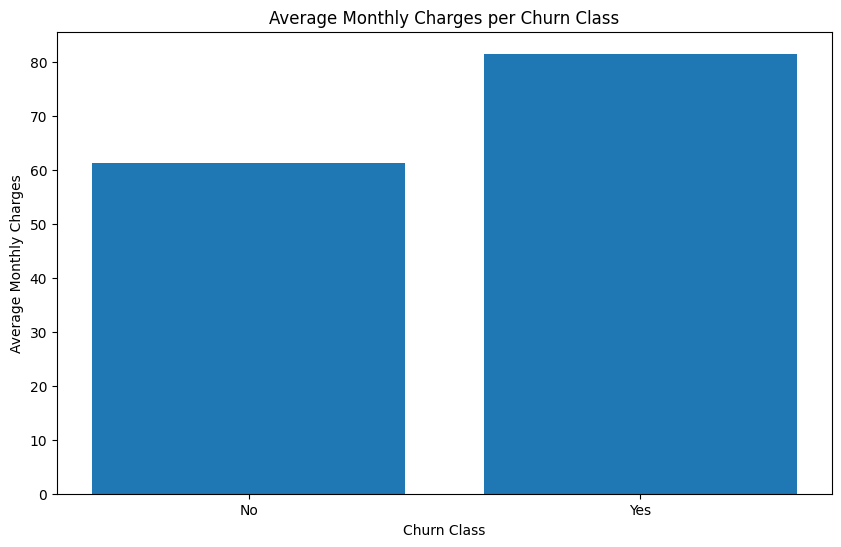

In [16]:
plt.figure(figsize=(10, 6))
plt.bar(monthly_charges_per_churn.index, monthly_charges_per_churn.values)

plt.xlabel('Churn Class')
plt.ylabel('Average Monthly Charges')
plt.title('Average Monthly Charges per Churn Class')

plt.show()

In [17]:
corr = df.corr(numeric_only=True)
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,-0.084307,0.229170,0.043508
tenure,-0.084307,1.000000,0.121923,0.768193
MonthlyCharges,0.229170,0.121923,1.000000,0.635205
TotalCharges,0.043508,0.768193,0.635205,1.000000


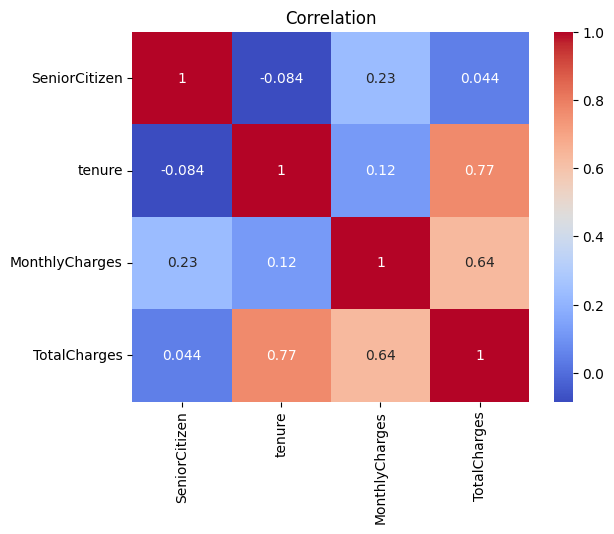

In [18]:
sns.heatmap(corr, cmap='coolwarm', annot=True)
plt.title('Correlation')
plt.show()

In [19]:
df.select_dtypes('object').nunique()

,0
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3
TechSupport,3


In [20]:
df['MultipleLines'].unique()

array(['No', 'Yes', 'No phone service'], dtype=object)

## Preprocessing

Scale numerical features

Encode categorical ones

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

from sklearn import set_config
set_config(display='diagram')

In [22]:
X = train_df.drop('Churn', axis=1)
y = train_df['Churn']

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [24]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

num_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler())])

In [25]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore')
)

cat_pipeline

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder', OneHotEncoder(handle_unknown='ignore'))])

In [26]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No


In [27]:
num_feat = ['MonthlyCharges', 'TotalCharges']
cat_feat = ['Partner', 'Dependents', 'PhoneService', 'gender', 'InternetService', 'Contract', 'PaymentMethod', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
pass_feat = ['SeniorCitizen']

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_feat),
    ('cat', cat_pipeline, cat_feat),
    ('pass', 'passthrough', pass_feat),
], remainder='drop')

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Partner', 'Dependents', 'PhoneService',
                                  'gender', 'InternetService', 'Contract',
                                  'PaymentMethod', 'MultipleLines',
                                  'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport',
                                  'StreamingTV', 'StreamingMovies',
                                  'PaperlessBilling']),
                                ('pass', 'passthrough', ['SeniorCitizen'])])

## Modelling

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

### Baseline

In [29]:
from sklearn.dummy import DummyClassifier

dummy_model = make_pipeline(preprocessor, DummyClassifier(strategy='most_frequent'))

dummy_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('dummyclassifier', DummyClassifier(strategy='most_frequent'))])

In [30]:
y_scores_baseline = dummy_model.predict_proba(X_val)
y_scores_baseline

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [31]:
roc_auc_score(y_val, y_scores_baseline[:, 1])

np.float64(0.5)

In [32]:
fpr_dummy, tpr_dummy, thresholds_dummy = roc_curve(y_val, y_scores_baseline[:, 1], pos_label='Yes')

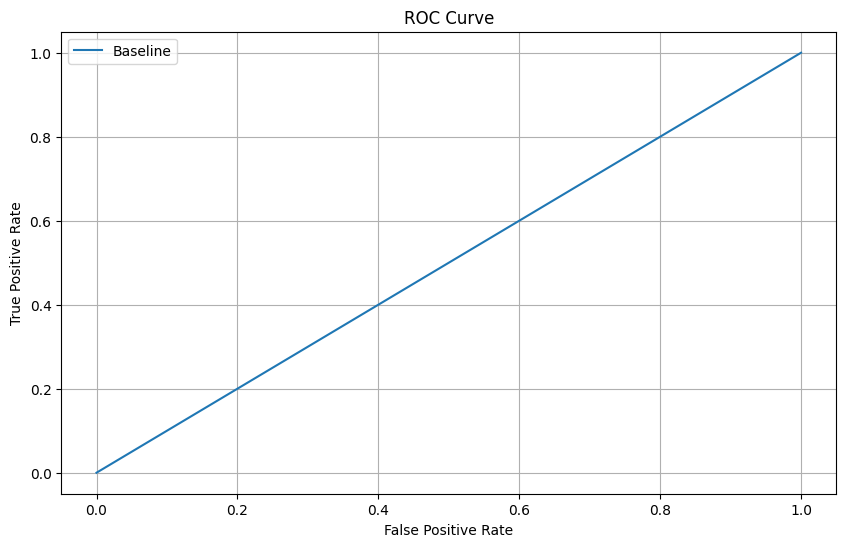

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

### Logistic Regression (with sampling methods)

In [34]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline as imblearn_make_pipeline

log_model = make_pipeline(preprocessor, LogisticRegression(random_state=42, n_jobs=-1))
log_model_over = imblearn_make_pipeline(preprocessor, RandomOverSampler(), LogisticRegression(random_state=42, n_jobs=-1))
log_model_under = imblearn_make_pipeline(preprocessor, RandomUnderSampler(), LogisticRegression(random_state=42, n_jobs=-1))

In [35]:
log_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('logisticregression',
                 LogisticRegression(n_jobs=-1, random_state=42))])

In [36]:
log_model_over.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('randomoversampler', RandomOverSampler()),
                ('logisticregression',
                 LogisticRegression(n_jobs=-1, random_state=42))])

In [37]:
log_model_under.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('randomundersampler', RandomUnderSampler()),
                ('logisticregression',
                 LogisticRegression(n_jobs=-1, random_state=42))])

In [38]:
y_scores_log = log_model.predict_proba(X_val)[:,1]
y_scores_log_over = log_model_over.predict_proba(X_val)[:,1]
y_scores_log_under = log_model_under.predict_proba(X_val)[:,1]

In [39]:
fpr_log, tpr_log, thresholds_log = roc_curve(y_val, y_scores_log, pos_label='Yes')
fpr_log_over, tpr_log_over, thresholds_log_over = roc_curve(y_val, y_scores_log_over, pos_label='Yes')
fpr_log_under, tpr_log_under, thresholds_log_under = roc_curve(y_val, y_scores_log_under, pos_label='Yes')

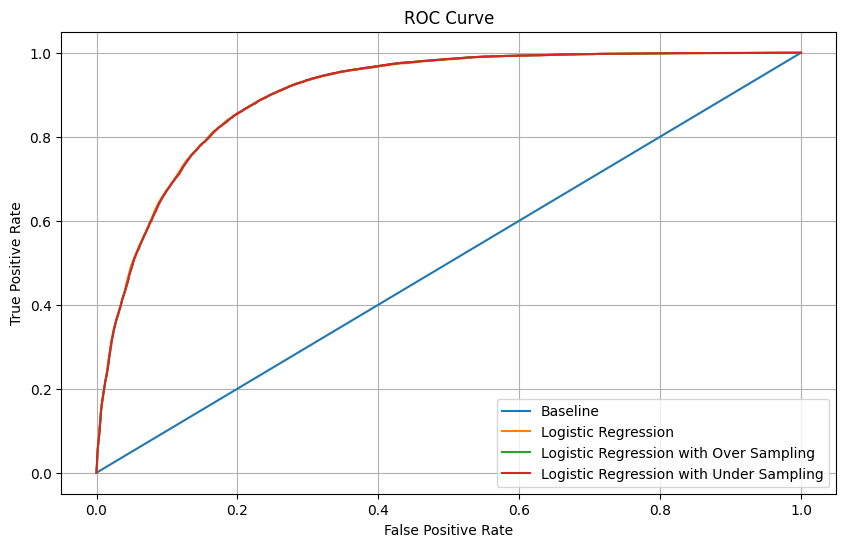

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_log_over, tpr_log_over, label='Logistic Regression with Over Sampling')
plt.plot(fpr_log_under, tpr_log_under, label='Logistic Regression with Under Sampling')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

The same roc curve for the three of them?

In [41]:
roc_auc_score(y_val, y_scores_log), roc_auc_score(y_val, y_scores_log_over), roc_auc_score(y_val, y_scores_log_under)

(np.float64(0.9040959546589205),
 np.float64(0.9039739676684757),
 np.float64(0.903936119334329))

In [42]:
log_model.score(X_val, y_val), log_model_over.score(X_val, y_val), log_model_under.score(X_val, y_val)

(0.8510085073082069, 0.8031959205311388, 0.8034483629111655)

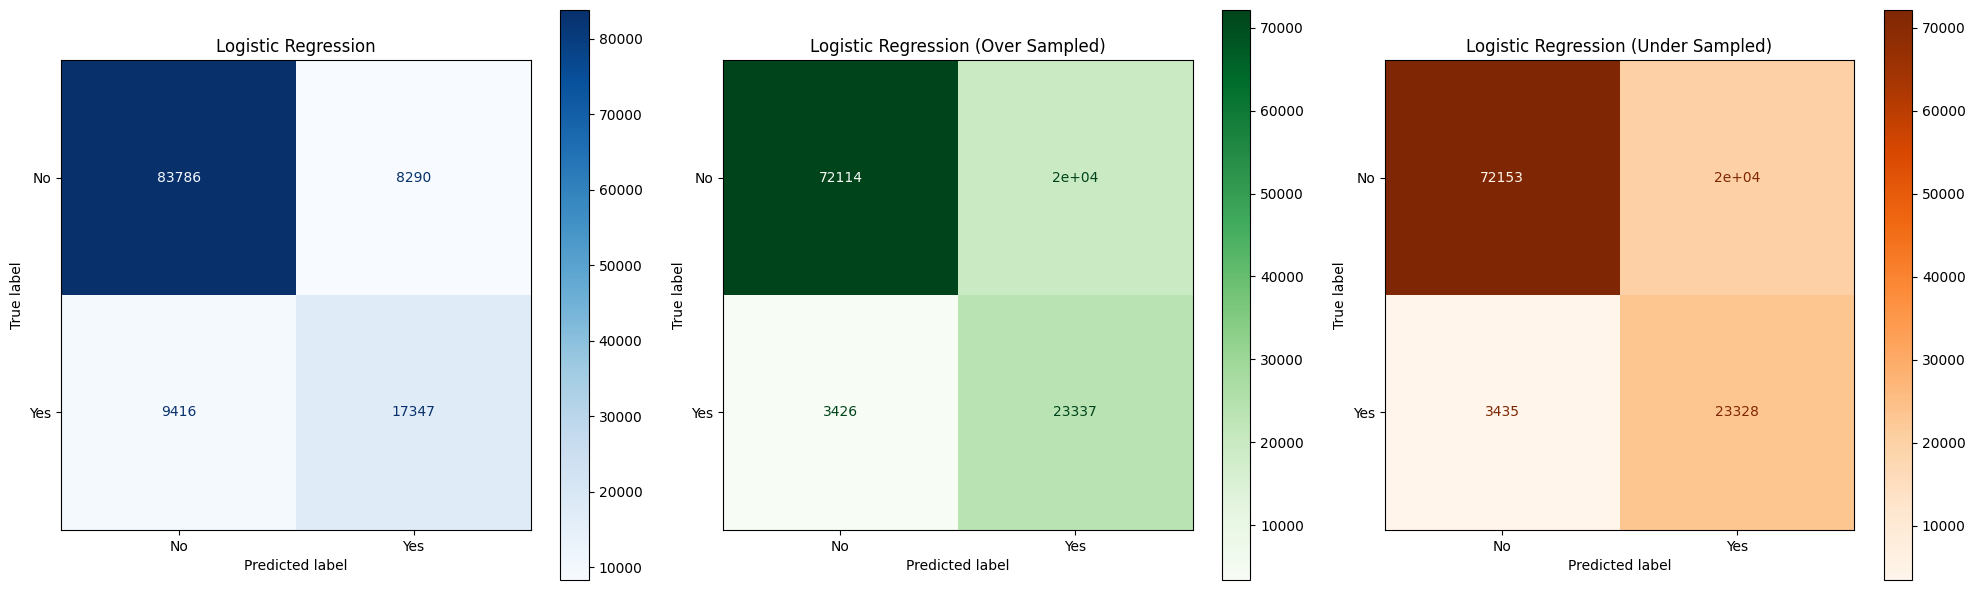

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ConfusionMatrixDisplay.from_estimator(log_model, X_val, y_val, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_estimator(log_model_over, X_val, y_val, ax=axes[1], cmap='Greens')
axes[1].set_title('Logistic Regression (Over Sampled)')

ConfusionMatrixDisplay.from_estimator(log_model_under, X_val, y_val, ax=axes[2], cmap='Oranges')
axes[2].set_title('Logistic Regression (Under Sampled)')

plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_val, log_model.predict(X_val)))
print(classification_report(y_val, log_model_over.predict(X_val)))
print(classification_report(y_val, log_model_under.predict(X_val)))

              precision    recall  f1-score   support

          No       0.90      0.91      0.90     92076
         Yes       0.68      0.65      0.66     26763

    accuracy                           0.85    118839
   macro avg       0.79      0.78      0.78    118839
weighted avg       0.85      0.85      0.85    118839

              precision    recall  f1-score   support

          No       0.95      0.78      0.86     92076
         Yes       0.54      0.87      0.67     26763

    accuracy                           0.80    118839
   macro avg       0.75      0.83      0.76    118839
weighted avg       0.86      0.80      0.82    118839

              precision    recall  f1-score   support

          No       0.95      0.78      0.86     92076
         Yes       0.54      0.87      0.67     26763

    accuracy                           0.80    118839
   macro avg       0.75      0.83      0.76    118839
weighted avg       0.86      0.80      0.82    118839



sampling increased recall as expected but it destroyed precision

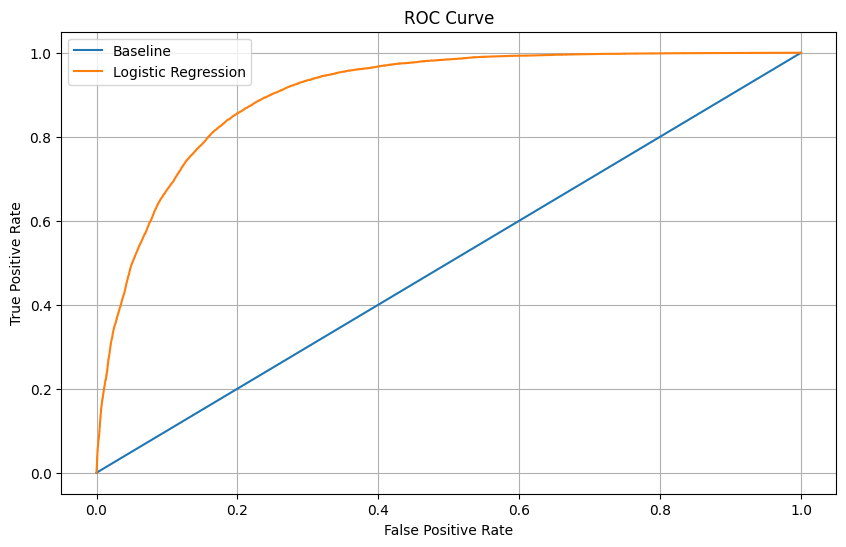

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

### Decision Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

tree_model = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))

tree_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [48]:
y_scores_tree = tree_model.predict_proba(X_val)[:,1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_val, y_scores_tree, pos_label='Yes')

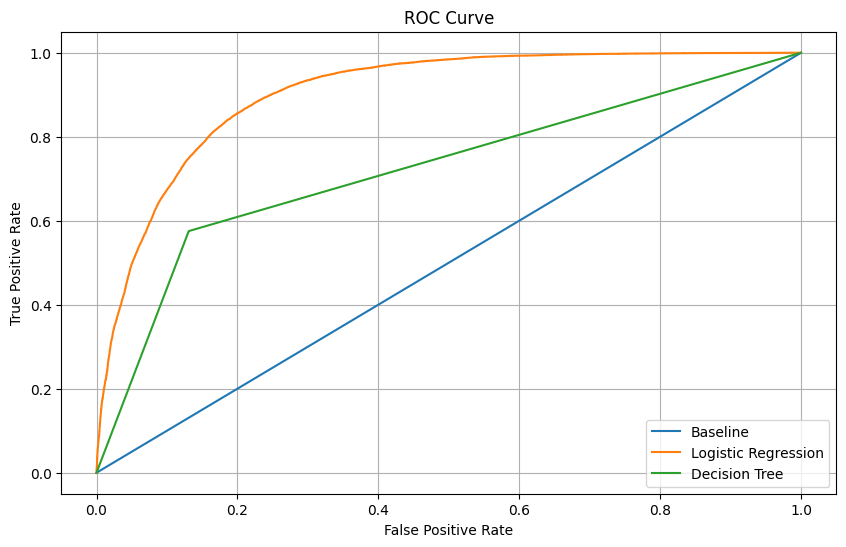

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

In [51]:
tree_model_tuned = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42, max_depth=10))

tree_model_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

In [52]:
y_scores_tree_tuned = tree_model_tuned.predict_proba(X_val)[:,1]

fpr_tree_tuned, tpr_tree_tuned, thresholds_tree_tuned = roc_curve(y_val, y_scores_tree_tuned, pos_label='Yes')

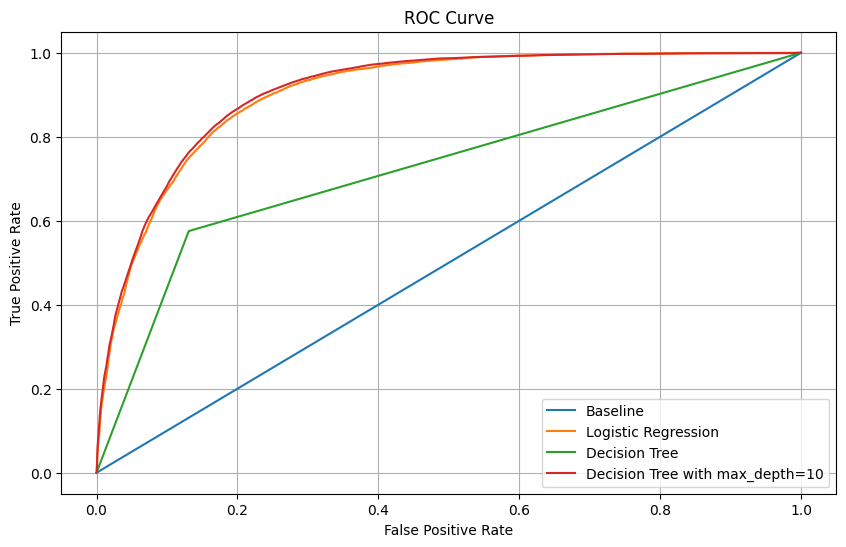

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_tree_tuned, tpr_tree_tuned, label='Decision Tree with max_depth=10')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

Decision Tree was overfitting without max_depth tuning

### Random Forest

In [54]:
from sklearn.ensemble import RandomForestClassifier

forest_model = make_pipeline(preprocessor, RandomForestClassifier(random_state=42, max_depth=10, n_jobs=-1))

forest_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=10, n_jobs=-1,
                                        random_state=42))])

In [55]:
y_scores_forest = forest_model.predict_proba(X_val)[:,1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_val, y_scores_forest, pos_label='Yes')

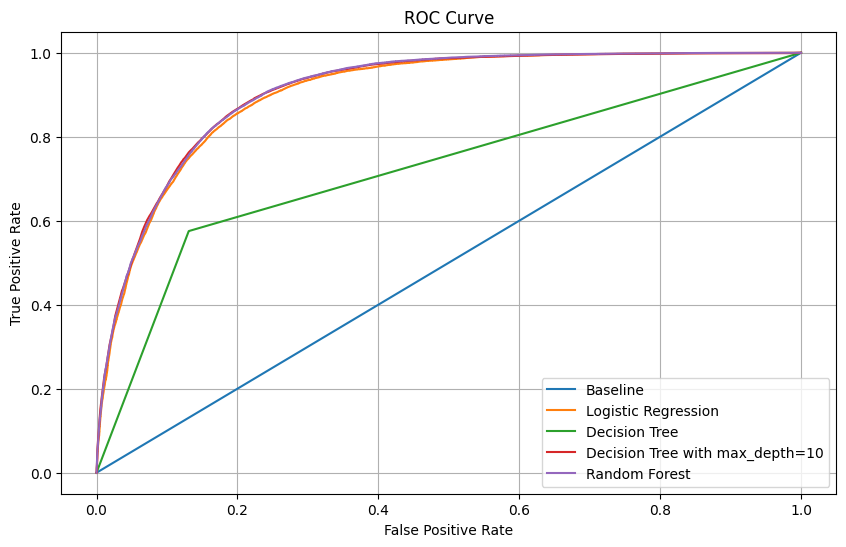

In [56]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_tree_tuned, tpr_tree_tuned, label='Decision Tree with max_depth=10')
plt.plot(fpr_forest, tpr_forest, label='Random Forest')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier

forest_model_tuned = make_pipeline(preprocessor, RandomForestClassifier(random_state=42, max_depth=10, n_estimators=500, n_jobs=-1))

forest_model_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore...
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=10, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

In [58]:
y_scores_forest_tuned = forest_model_tuned.predict_proba(X_val)[:,1]

fpr_forest_tuned, tpr_forest_tuned, thresholds_forest_tuned = roc_curve(y_val, y_scores_forest_tuned, pos_label='Yes')

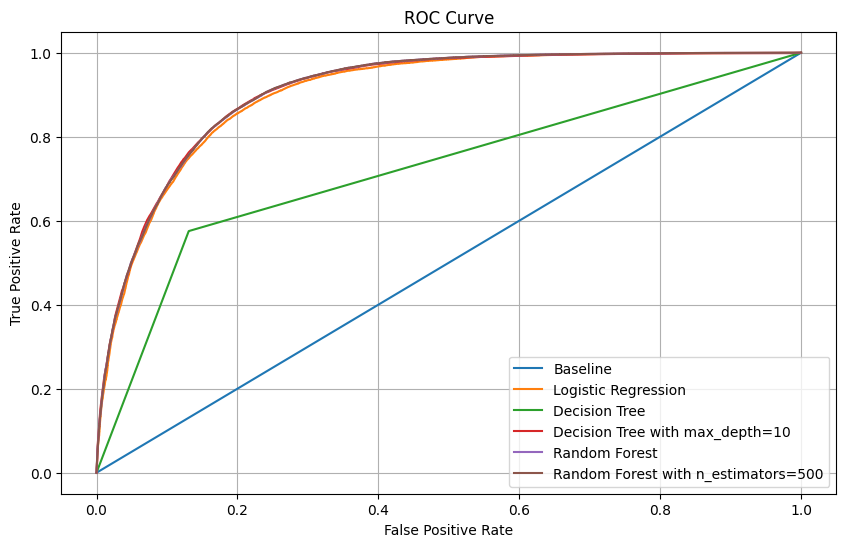

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_tree_tuned, tpr_tree_tuned, label='Decision Tree with max_depth=10')
plt.plot(fpr_forest, tpr_forest, label='Random Forest')
plt.plot(fpr_forest_tuned, tpr_forest_tuned, label='Random Forest with n_estimators=500')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

Tuned Random Forest doesn't show a big diffrence

### Gradient Boosting Tree

In [61]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = make_pipeline(preprocessor, GradientBoostingClassifier(random_state=42))

gb_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(random_state=42))])

In [62]:
y_scores_gb = gb_model.predict_proba(X_val)[:,1]

fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_val, y_scores_gb, pos_label='Yes')

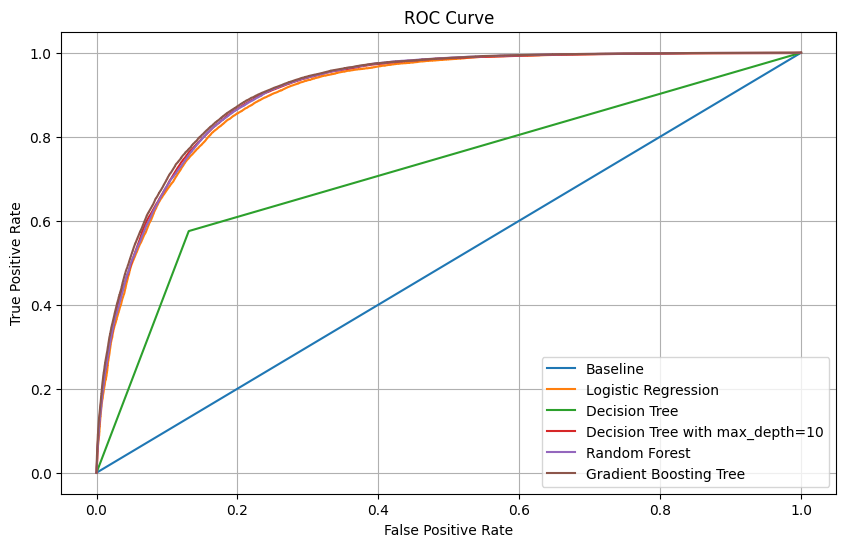

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_dummy, tpr_dummy, label='Baseline')
plt.plot(fpr_log, tpr_log, label='Logistic Regression')
plt.plot(fpr_tree, tpr_tree, label='Decision Tree')
plt.plot(fpr_tree_tuned, tpr_tree_tuned, label='Decision Tree with max_depth=10')
plt.plot(fpr_forest, tpr_forest, label='Random Forest')
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting Tree')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

In [64]:
models = {
    'Baseline': dummy_model,
    'Logistic Regression': log_model,
    'Logistic Regression (Over Sampled)': log_model_over,
    'Logistic Regression (Under Sampled)': log_model_under,
    'Decision Tree': tree_model,
    'Decision Tree (Tuned)': tree_model_tuned,
    'Random Forest': forest_model,
    'Random Forest (Tuned)': forest_model_tuned,
    'Gradient Boosting Tree': gb_model,
}

for name, model in models.items():
    y_scores = model.predict_proba(X_val)[:,1]
    auc_score = roc_auc_score(y_val, y_scores)
    print(f'{name}: {auc_score}')

Baseline: 0.5
Logistic Regression: 0.9040959546589205
Logistic Regression (Over Sampled): 0.9039739676684757
Logistic Regression (Under Sampled): 0.903936119334329
Decision Tree: 0.7222031590664987
Decision Tree (Tuned): 0.9085481444112675
Random Forest: 0.9087051677012543
Random Forest (Tuned): 0.9088086844189479
Gradient Boosting Tree: 0.9123575230186671


In [74]:
gb_model.fit(X, y)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Partner', 'Dependents',
                                                   'PhoneService', 'gender',
                                                   'InternetService',
                                                   'Contract', 'PaymentMethod',
                                                   'MultipleLines',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'PaperlessBilling']),
                                                 ('pass', 'passthrough',
                                                  ['SeniorCitizen'])])),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(random_state=42))])

In [75]:
y_scores = gb_model.predict_proba(test_df)[:,1]

In [76]:
submission = pd.DataFrame(y_scores, index=test_df.index, columns=['Churn'])
submission.head()

In [77]:
submission.to_csv('/content/drive/MyDrive/Colab Notebooks/Predict-Customer-Churn--playground-6-3/data/submission.csv', sep=',')